In [1]:
import numpy as np
import netket as nk
import numpy as np
import matplotlib.pyplot as plt
import json
from pyscf import gto, scf, fci
import netket.experimental as nkx
from tqdm import tqdm
import matplotlib.pyplot as plt
import sys
sys.path.append('.')  # 添加当前目录到路径

from h2_excited_states import (
    setup_h2_system,
    compute_ground_state,
    compute_1st_excited_state,
    compute_2nd_excited_state,
)
bond_distance = np.round(np.linspace(0.2,1.4,15),2)

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/netket/utils/dispatch.py:25: FutureWarning: 
The variables `nk.utils.dispatch.{TrueT|FalseT|Bool}` are deprecated. Their usages
should instead be replaced by the following objects:

    `TrueT` should be replaced by `typing.Literal[True]`
    `FalseT` should be replaced by `typing.Literal[False]`
    `Bool` should be replaced by `bool`

  _warn_deprecation(
/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/netket/driver/vmc_common.py:33: FutureWarning: 

            `nk.driver.vmc_common is deprecated and the functionality removed.   

If you imported `nk.driver.vmc_common`, you must reimplement that functionality yourself.


  warn_deprecation(


In [2]:
import jax
import jax.numpy as jnp
import pennylane as qml
from flax import nnx
from functools import partial
import numpy as np
from QNN_jax import initialize_parameters
import jax
jax.config.update("jax_enable_x64", True)
# -------------------------- 第一步：改造量子电路，原生支持Batch输入 --------------------------
def quantum_neural_network(x, params, n_qubits, n_layers):
    """
    兼容Batch的量子电路核心逻辑：
    - x: 输入张量，形状为 (batch_size, n_qubits)（Batch维度在前）
    - params: 量子电路参数，形状为 (n_layers, 2 * n_qubits)
    - 所有量子门操作自动沿Batch维度向量化，无需手动循环
    """
    # 1. 强制将输入转为JAX张量（兼容np.array/其他格式），并确保是二维（batch, n_qubits）
    x = jnp.atleast_2d(x)
    # 校验特征维度（Batch维度不校验，由NNX自动兼容）
    if x.shape[-1] != n_qubits:
        raise ValueError(f"输入特征维度需为{n_qubits}，当前为{x.shape[-1]}")
    
    # 2. 数据编码：向量化RX门（自动兼容Batch）
    # qml.RX支持批量角度输入，会自动为每个Batch样本应用对应角度的门
    for i in range(n_qubits):
        qml.RX(x[:, i] * jnp.pi, wires=i)  # x[:, i] 取所有Batch样本的第i个特征
    
    # 3. 变分层：向量化旋转/纠缠门（Batch维度自动兼容）
    for layer in range(n_layers):
        # 纠缠层（CNOT无参数，Batch不影响）
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i+1])
        qml.Barrier(wires=range(n_qubits))
        # 旋转层：参数向量化，自动适配Batch
        for i in range(n_qubits):
            qml.RX(params[layer, 2*i], wires=i)  # RX参数
            qml.RZ(params[layer, 2*i+1], wires=i)  # RZ参数
    # 4. 测量：返回每个量子比特的期望值

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

In [3]:
n_qubits = 4
n_layers = 2
dev = qml.device("default.qubit", wires=n_qubits)
# 封装QNode：interface="jax" 确保兼容JAX/NNX的Batch计算
qnode = qml.QNode(quantum_neural_network, dev, interface="jax")
# 测试单个输入
params = initialize_parameters(n_layers, n_qubits)
result = qnode(x=[1,0,1,0], params=params, n_layers=n_layers, n_qubits=n_qubits)
print("单个输入结果:", result)
result

单个输入结果: [Array([0.21062209], dtype=float64), Array([0.09039875], dtype=float64), Array([-0.27025594], dtype=float64), Array([-0.19796214], dtype=float64)]


[Array([0.21062209], dtype=float64),
 Array([0.09039875], dtype=float64),
 Array([-0.27025594], dtype=float64),
 Array([-0.19796214], dtype=float64)]

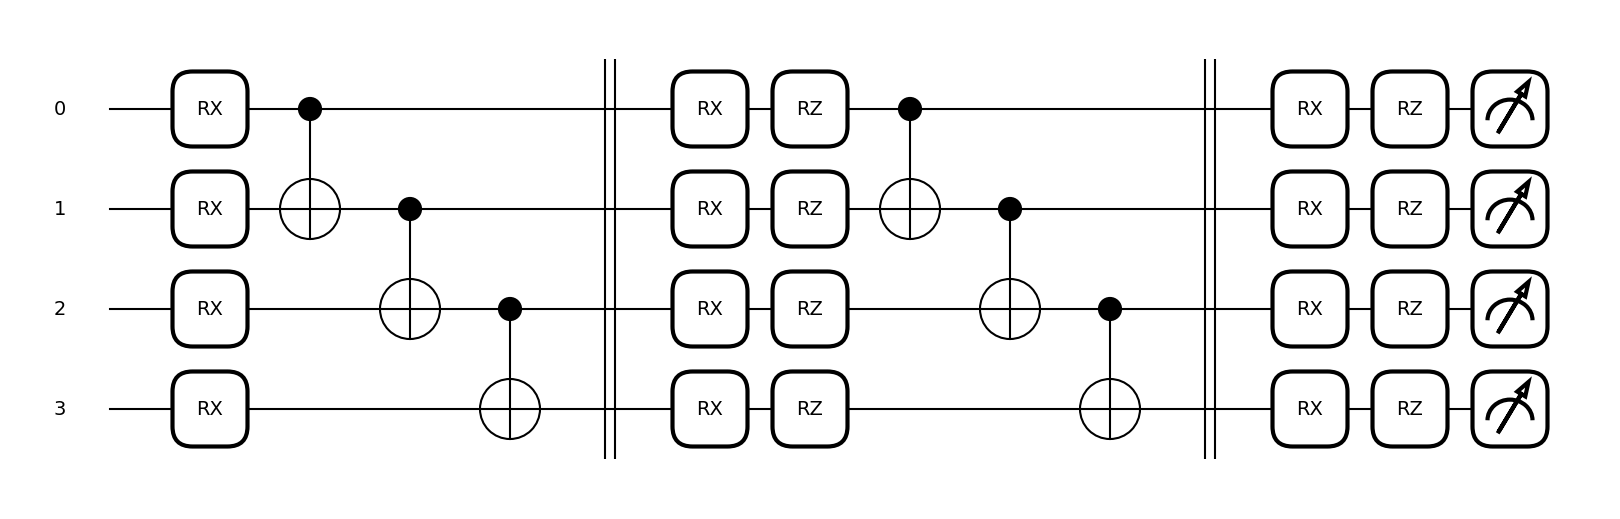

In [4]:
import matplotlib.pyplot as plt
qml.drawer.use_style("black_white")
fig, ax = qml.draw_mpl(qnode)(x=[1,0,1,0],params=initialize_parameters(2,4),n_layers=2,n_qubits=4)
plt.show()

In [5]:
def qnn_circuit(n_qubits:int,n_layers:int):
    dev = qml.device('default.qubit',wires=n_qubits)
    pqc_node = qml.QNode(func=quantum_neural_network,device=dev,interface='jax')
    qnn_node_circuit = partial(pqc_node,n_qubits=n_qubits,n_layers=n_layers)
    return qnn_node_circuit

In [6]:
import jax
import jax.numpy as jnp
from flax import nnx

class FFN_Amplitude(nnx.Module):

    def __init__(self, N: int, alpha: int = 1, *, rngs: nnx.Rngs):
        self.alpha = alpha
        self.linear = nnx.Linear(in_features=N, out_features=alpha * N, rngs=rngs)

    def __call__(self, x: jax.Array):
        y = self.linear(x)
        y = nnx.relu(y)
        return jnp.sum(y, axis=-1)
    

class FFN_Phase(nnx.Module):

    def __init__(self, N: int, alpha: int = 1, *, rngs: nnx.Rngs):
        self.alpha = alpha
        self.linear = nnx.Linear(in_features=N, out_features=alpha * N, rngs=rngs)

    def __call__(self, x: jax.Array):
        y = self.linear(x)
        y = nnx.relu(y)
        return jnp.sum(y, axis=-1)  

In [7]:
from flax import nnx
from functools import partial
class QNNLinear(nnx.Module):
    def __init__(self, rngs: nnx.Rngs,n_qubits:int,n_layer:int):
        key = rngs.params()
        # 不存储PRNGKey，直接使用rngs.params()初始化参数
        self.n_qubits,self.n_layer = n_qubits,n_layer
        self.qnn_params = nnx.Param(jax.random.normal(key, (self.n_layer, 2*self.n_qubits), dtype=jnp.float32))
        self.qnn_layer = partial(qnn_circuit, n_qubits=self.n_qubits, n_layers=self.n_layer)()
        self.Linear = nnx.Linear(in_features=self.n_qubits,out_features=self.n_qubits,use_bias=False,rngs=rngs)
        
    
    def __call__(self, s:np.array):
        # 确保输入是JAX数组
        s = jnp.array(s, dtype=jnp.float32)
        # 获取QNN输出
        qnn_output = self.qnn_layer(x=s,params=self.qnn_params) #dtype=float32
        # 将QNN输出转换为float32类型
        #qnn_output = jnp.array(qnn_output, dtype=jnp.float32).reshape(-1,self.n_qubits)
        qnn_output = jnp.stack(qnn_output, axis=1)  # 形状: (batch_size, n_qubits)
        qnn_output = jnp.array(qnn_output, dtype=jnp.float32)
        y = self.Linear(qnn_output)
        y = nnx.relu(y)
        return jnp.sum(y, axis=-1)
    
class QNN_Hybrid(nnx.Module):
    def __init__(self, rngs_real: nnx.Rngs,rngs_imag:nnx.Rngs,n_qubits:int,n_layer:int):
        self.qnn_real = QNNLinear(rngs_real,n_qubits,n_layer)
        self.qnn_imag = QNNLinear(rngs_imag,n_qubits,n_layer)
        
        
    def __call__(self, s:np.array):
        real = self.qnn_real(s)
        imag = self.qnn_imag(s)
        return real + 1j*imag
    
class FFN_QNN_Hybrid(nnx.Module):
    def __init__(self, 
                 rngs_real: nnx.Rngs,
                 rngs_imag:nnx.Rngs,
                 rngs_amplitude:nnx.Rngs,
                 rngs_phase:nnx.Rngs,
                 n_qubits:int,
                 n_layer:int,
                 alpha:int):
        
        self.qnn_real = QNNLinear(rngs_real,n_qubits,n_layer)
        self.qnn_imag = QNNLinear(rngs_imag,n_qubits,n_layer)
        self.ffn_amplitude = FFN_Amplitude(N=n_qubits,alpha=alpha,rngs=rngs_amplitude)
        self.ffn_phase = FFN_Phase(N=n_qubits,alpha=alpha,rngs=rngs_phase)
        
    def __call__(self, s:np.array):
        ffnn_amplitude = self.ffn_amplitude(s)
        ffnn_phase = self.ffn_phase(s)
        qnn_real = self.qnn_real(s)
        qnn_imag = self.qnn_imag(s)
        
        return ffnn_amplitude+qnn_real+1j*ffnn_phase+1j*qnn_imag
        

In [8]:
hybrid_model = FFN_QNN_Hybrid(
                      rngs_real=nnx.Rngs(0),
                      rngs_imag=nnx.Rngs(1),
                      rngs_amplitude=nnx.Rngs(2),
                      rngs_phase=nnx.Rngs(3),
                      n_qubits=4,
                      n_layer=2,
                      alpha=1)


In [9]:
bond_distance[0]=1.74
# 步骤1：设置H2分子系统
mol, ha, hi, sampler, e_fci_all, E_fci = setup_h2_system(bond_length=1.74)

Hartree-Fock能量: -0.84390759 Ha
FCI基态能量: -0.96730577 Ha

FCI所有能级:
  E0 (基态) = -0.96730577 Ha
  E1 (第1激发态) = -0.91306114 Ha
  E2 (第2激发态) = -0.42410252 Ha
  E3 (第3激发态) = -0.35953957 Ha

Hilbert空间维度: 4
空间轨道数: 2
电子数: 2


In [11]:
# 步骤2：计算基态
vs_gs, final_energy_gs, gs_params = compute_ground_state(
    ha=ha,
    sampler=sampler,
    n_iter=300,
    model=hybrid_model,
    learning_rate=0.1,
    diag_shift=0.01,
    n_discard_per_chain=10,
    n_samples=512,
    output_path=f'Data_H2/Hybrid/ground_state_{bond_distance[0]}A'
)


开始计算基态...


100%|██████████| 300/300 [02:06<00:00,  2.37it/s, Energy=-0.96720+0.00000j ± 0.00011 [σ²=0.00001, R̂=1.0141]]        

基态能量: -0.96719796 Ha


In [12]:
# 步骤3：计算第一激发态
vs_ex1, final_energy_ex1, ex1_params, vs_gs = compute_1st_excited_state(
    ha=ha,
    sampler=sampler,
    gs_params=gs_params,
    e_fci=E_fci,
    n_iter=500,
    model=hybrid_model,
    learning_rate=0.1,
    diag_shift=0.01,
    n_discard_per_chain=10,
    n_samples=512,
    shift=2.5,  # 关键参数：使用0.3而不是1.0
    output_path=f'Data_H2/Hybrid/excited_state_1_1.74A'
)


开始计算第一激发态 (shift=2.5)...


100%|██████████| 500/500 [07:18<00:00,  1.14it/s, Energy=-0.910760+0.000161j ± 0.000014 [σ²=0.000000, R̂=1.0169]]    

第一激发态能量: -0.91076046 Ha
激发能: 0.05654531 Ha


In [14]:
# 步骤4：计算第二激发态
vs_ex2, final_energy_ex2, ex2_params, vs_gs, vs_ex1_loaded = compute_2nd_excited_state(
    ha=ha,
    sampler=sampler,
    gs_params=gs_params,
    ex1_params=ex1_params,
    e_fci=E_fci,
    n_iter=500,
    model=hybrid_model,
    learning_rate=0.1,
    diag_shift=0.01,
    n_discard_per_chain=10,
    n_samples=512,
    shift=2.5,  # 关键参数：使用0.3而不是1.0
    output_path=f'Data_H2/Hybrid/excited_state_2_{bond_distance[0]}A'
)


开始计算第二激发态 (shift=2.5)...


100%|██████████| 500/500 [10:08<00:00,  1.22s/it, Energy=-0.43290-0.00019j ± 0.00049 [σ²=0.00014, R̂=1.0445]]

第二激发态能量: -0.43290095 Ha
激发能: 0.53440482 Ha


In [ ]:
# 步骤4：计算第二激发态
vs_ex2_lamada_5, final_energy_ex2_lamada_5, ex2_params_lamada_5, vs_gs, vs_ex1_loaded = compute_2nd_excited_state(
    ha=ha,
    sampler=sampler,
    gs_params=gs_params,
    ex1_params=ex1_params,
    e_fci=E_fci,
    n_iter=500,
    model=model_rbm,
    learning_rate=0.1,
    diag_shift=0.01,
    n_discard_per_chain=10,
    n_samples=512,
    shift=5,  # 关键参数：使用0.3而不是1.0
    output_path=f'Data_H2/RBM/excited_state_2_{bond_distance[0]}A_lamada_5'
)

In [15]:
import json
import matplotlib.pyplot as plt
with open('./Data_H2/Hybrid/ground_state_1.74A.log', 'r') as f:
    data_gs = json.load(f)

with open('./Data_H2/Hybrid/excited_state_1_1.74A.log', 'r') as f:
    data_ex1 = json.load(f)
    
with open('./Data_H2/Hybrid/excited_state_2_1.74A.log', 'r') as f:
    data_ex2 = json.load(f)
iter_gs = data_gs["Energy"]["iters"]
iter_ex1 = data_ex1["Energy"]["iters"]
iter_ex2 = data_ex2["Energy"]["iters"]



energy_gs = data_gs["Energy"]["Mean"]['real']
energy_ex1 = data_ex1["Energy"]["Mean"]['real']
#energy_ex1[0]=energy_ex1[1]
energy_ex2 = data_ex2["Energy"]["Mean"]['real']
#energy_ex2[0]=energy_ex2[1]


In [ ]:
e_fci_all

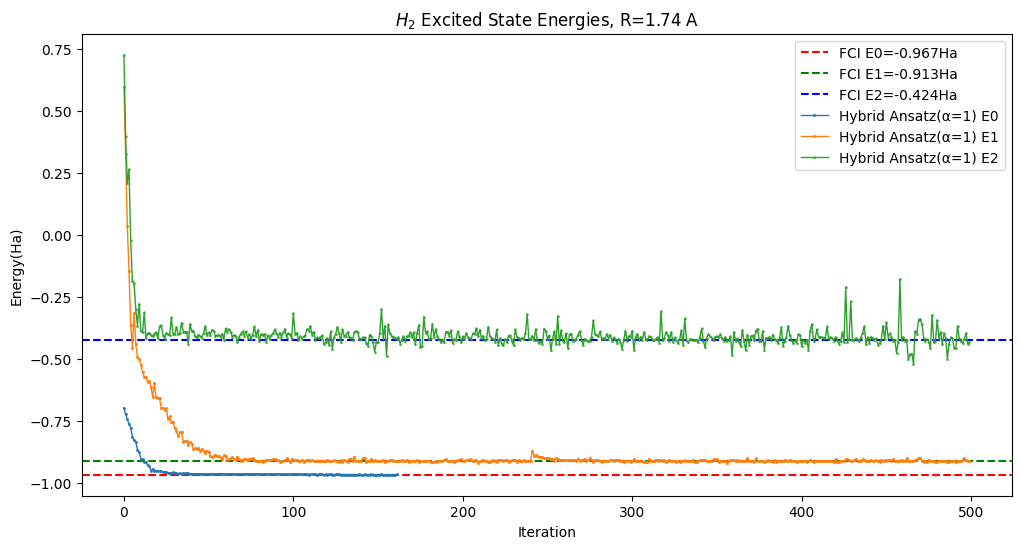

In [18]:
plt.figure(figsize=(12, 6))
plt.xlabel('Iteration')
plt.ylabel('Energy(Ha)')
plt.title('$H_2$ Excited State Energies, R=1.74 A')
plt.axhline(e_fci_all[0], color='r', linestyle='--', label=f'FCI E0={e_fci_all[0]:.3f}Ha')
plt.axhline(e_fci_all[1], color='g', linestyle='--', label=f'FCI E1={e_fci_all[1]:.3f}Ha')
plt.axhline(e_fci_all[2], color='b', linestyle='--', label=f'FCI E2={e_fci_all[2]:.3f}Ha')
plt.plot(iter_gs, energy_gs, 'o-', label='Hybrid Ansatz(α=1) E0', linewidth=1, markersize=1)
plt.plot(iter_ex1, energy_ex1, 's-', label='Hybrid Ansatz(α=1) E1', linewidth=1, markersize=1)
plt.plot(iter_ex2, energy_ex2, '^-', label='Hybrid Ansatz(α=1) E2', linewidth=1, markersize=1)
plt.legend()


In [ ]:
with open('./Data_H2/RBM/excited_state_2_0.2A_lamada_5.log', 'r') as f:
    data_ex2_lamada_5 = json.load(f)
iter_ex2_lamada_5 = data_ex2_lamada_5['Energy']['iters']
energy_ex2_lamada_5 = data_ex2_lamada_5['Energy']['Mean']['real']

In [ ]:
plt.figure(figsize=(12, 6))
plt.xlabel('Iteration')
plt.ylabel('Energy(Ha)')
plt.title('$H_2$ Excited State Energies, R=0.2 A')
#plt.axhline(e_fci_all[0], color='r', linestyle='--', label='FCI E0')
plt.axhline(e_fci_all[1], color='g', linestyle='--', label='FCI E1')
plt.axhline(e_fci_all[2], color='b', linestyle='--', label='FCI E2')
#plt.plot(iter_gs, energy_gs, 'o-', label='RBM Ansatz(α=1) E0', linewidth=1, markersize=1)
# plt.plot(iter_ex1, energy_ex1, 's-', label='RBM Ansatz(α=1) E1', linewidth=1, markersize=1)
plt.plot(iter_ex2, energy_ex2, '^-', label='RBM Ansatz(α=1) E2 λ=2.5', linewidth=1, markersize=1)
plt.plot(iter_ex2_lamada_5, energy_ex2_lamada_5, 'D-', label='RBM Ansatz(α=1) E2, λ=5', linewidth=1, markersize=1)
plt.legend()
